# Anon Tokyo — Solar Filament Segmentation 2026

**Global context → native detail → auditable instances.**

This notebook documents the complete data, training, validation, inference and export workflow. The accompanying four-page report explains the experiments and uncertainty. Contact: pufanzhang1@gmail.com.

Run all cells to inspect the packaged results. For fresh inference, install `requirements.txt`, attach the official competition data after accepting its rules, and set `RUN_INFERENCE=True` below. The published checkpoint manifest provides all trained weights; no private local cache is needed. Training is an optional, separately enabled path and is substantially more expensive.

GPU reference: RTX 5090 32 GB, PyTorch 2.8.0 + CUDA 12.8, Python 3.12. A CUDA GPU is required by the native refiner. Reproduction on different hardware may change threshold-edge pixels; every output is independently audited.

In [1]:
from pathlib import Path
import os, sys, json, subprocess, hashlib
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
assert (ROOT / "filament").is_dir(), "Open this notebook from the repository root."
RUN_INFERENCE = False
RUN_TRAINING = False
RUN_VALIDATION = False
TRAIN_FOLDS = [0]  # Set list(range(5)) for the entire fold ensemble.
TRAIN_V2 = False   # Enable with all five folds to retrain the released mixture.
OFFICIAL_DATA = Path(os.environ.get("FILAMENT_DATA_DIR", ROOT / "data/MAGFiLO_1.0_Kaggle_2026"))
def run(module, *args):
    subprocess.run([sys.executable, "-m", module, *map(str, args)], cwd=ROOT, check=True)
release = json.loads((ROOT / "artifacts/release.json").read_text())
print("Team:", release["team"])
print("Selected pipeline:", release["pipeline_config"])
print("Recorded public score:", release["public_score"])


Team: Anon Tokyo
Selected pipeline: configs/pipeline_release_mixed.json
Recorded public score: 0.38


## 1. Pipeline and data protocol

707 physical training images contain 1,154 independent annotator-image records and 8,199 instances. Five folds keep every annotation of an image and nearby observation groups together. Only segmentation masks supervise task training. The input remains the provided grayscale H-alpha image.

The first stage uses ConvNeXt-Tiny with foreground/boundary heads. Three-view flip TTA is averaged before proposal extraction. Native 384-pixel crops feed a four-channel ResNet18 U-Net refiner, followed by learned rejection, Gaussian-prior blending and exclusive pixel allocation. See the release configuration for the exact final ensemble.

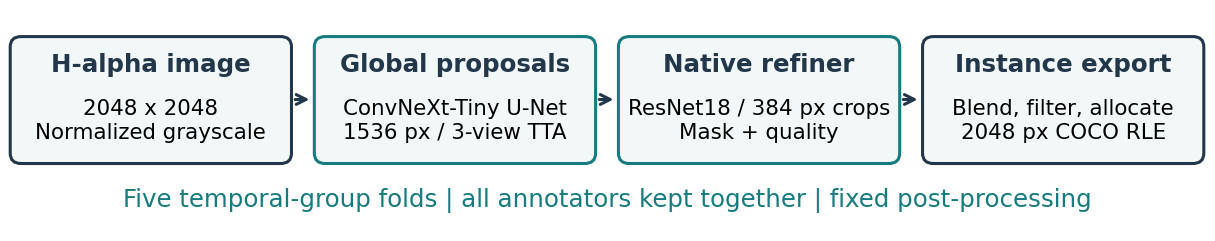

,images,groups
fold,,
0,142,66
1,143,69
2,141,65
3,140,64
4,141,67


In [2]:
display(Image(filename=str(ROOT / "report/figures/pipeline.png")))
folds = pd.read_csv(ROOT / "artifacts/folds.csv")
display(folds.groupby("fold").agg(images=("image_id", "size"), groups=("group", "nunique")))


## 2. Prepare official data

Place the extracted `MAGFiLO_1.0_Kaggle_2026` directory under `data/`, or set `FILAMENT_DATA_DIR` to its location. The repository contains no credentials. `scripts.download_data` can download the data when a user supplies their own `KAGGLE_API_TOKEN` environment variable.

`prepare_data` reconstructs the exact frozen manifest from the official archive. Its hash must match the release. Memory-mapped caches accelerate training; they are not required for test inference.

In [3]:
if RUN_TRAINING or RUN_VALIDATION:
    target = ROOT / "data/MAGFiLO_1.0_Kaggle_2026"
    if not target.exists():
        assert OFFICIAL_DATA.is_dir(), "Attach official competition data first."
        target.parent.mkdir(exist_ok=True)
        target.symlink_to(OFFICIAL_DATA.resolve(), target_is_directory=True)
    if not (ROOT / "data/manifest.json").exists():
        run("scripts.prepare_data", "--size", 1024, "--workers", 4)
    digest = hashlib.sha256((ROOT / "data/manifest.json").read_bytes()).hexdigest()
    assert digest == release["manifest_sha256"]
    if RUN_TRAINING:
        for size in [1024, 1536, 2048]:
            run("scripts.build_fast_cache", "--size", size, "--pack-targets")
else:
    print("Data preparation is enabled by RUN_TRAINING, or automatically during fresh inference.")


Data preparation is enabled by RUN_TRAINING, or automatically during fresh inference.


## 3. Train the global model and native refiner

The following uses new run names to protect released checkpoints. `TRAIN_FOLDS=[0]` demonstrates the baseline path. Set `TRAIN_FOLDS=list(range(5))` and `TRAIN_V2=True` to retrain all twelve models in the released mixture. Tiny uses 30/24 epochs; V2-Base uses 40/18 epochs at 1024/1536 resolution, with effective batch four. The generated `configs/pipeline_retrained.json` points to these newly fitted models; run it with `scripts.predict_pipeline --split test` to evaluate their predictions separately from the released weights. The experiment registry preserves the settings and epoch histories of the actual runs, including resumed runs. Resumed worker RNG streams and GPU numerical differences mean fresh training is not promised to be byte-identical.

The refiner receives proposals only from the outer training observations. No held-out fold labels enter either model. The full-data deployment variant uses `--all-data` and refiner fold `-1`; it has no validation fold and cannot be counted as OOF evidence.

In [4]:
if RUN_TRAINING:
    for FOLD in TRAIN_FOLDS:
        coarse = f"reproduce_f{FOLD}_1024"
        native = f"reproduce_f{FOLD}_1536"
        refiner = f"reproduce_refiner_f{FOLD}"
        run("scripts.train", "--kind", "semantic", "--fold", FOLD, "--size", 1024,
            "--batch", 2, "--accum", 2, "--epochs", 30, "--lr", .0003,
            "--workers", 4, "--name", coarse)
        run("scripts.train", "--kind", "semantic", "--fold", FOLD, "--size", 1536,
            "--batch", 4, "--epochs", 24, "--lr", .0001, "--val-every", 3,
            "--workers", 4, "--init", f"runs/{coarse}/best.pt", "--name", native)
        run("scripts.predict", "--checkpoint", f"runs/{coarse}/best.pt", "--split", "train",
            "--threshold", .5, "--min-area", 64, "--output", f"runs/{coarse}/train_proposals")
        run("scripts.train_refiner", "--predictions", f"runs/{coarse}/train_proposals",
            "--fold", FOLD, "--epochs", 12, "--samples", 6000, "--size", 384,
            "--batch", 48, "--workers", 4, "--name", refiner)
    if TRAIN_V2:
        for FOLD in [0, 1]:
            coarse = f"reproduce_v2_f{FOLD}_1024"
            native = f"reproduce_v2_f{FOLD}_1536"
            encoder = "tu-convnextv2_base.fcmae_ft_in22k_in1k"
            run("scripts.train", "--kind", "semantic", "--encoder", encoder,
                "--fold", FOLD, "--size", 1024, "--batch", 4, "--epochs", 40,
                "--lr", .0003, "--val-every", 4, "--workers", 4, "--name", coarse)
            run("scripts.train", "--kind", "semantic", "--encoder", encoder,
                "--fold", FOLD, "--size", 1536, "--batch", 2, "--accum", 2,
                "--epochs", 18, "--lr", .0001, "--val-every", 3, "--workers", 4,
                "--init", f"runs/{coarse}/best.pt", "--name", native)
    if set(TRAIN_FOLDS) == set(range(5)) and TRAIN_V2:
        config = json.loads((ROOT / "configs/pipeline_release_mixed.json").read_text())
        for fold in range(5):
            config["models"][fold]["checkpoint"] = f"runs/reproduce_f{fold}_1536/best.pt"
            config["refiners"][fold]["checkpoint"] = f"runs/reproduce_refiner_f{fold}/epoch_12.pt"
        for fold in [0, 1]:
            config["models"][5 + fold]["checkpoint"] = f"runs/reproduce_v2_f{fold}_1536/best.pt"
        (ROOT / "configs/pipeline_retrained.json").write_text(json.dumps(config, indent=2))
        print("Retrained inference configuration: configs/pipeline_retrained.json")
else:
    print("Training disabled. Released weights support inference without retraining.")


Training disabled. Released weights support inference without retraining.


## 4. Evaluate without conflating validation and test

The official count-based PQ evaluates every annotator separately and aggregates counts globally. The strict one-to-one diagnostic is reported alongside it. Fold 0 was used for development; the other folds confirm the fixed refinement recipe. Temporal-group bootstrap intervals are conditional on fitted predictions and are not nested selection intervals.

The coarse comparison uses a 256-pixel area threshold; the refined recipe uses 64 pixels plus learned filtering. The reported improvement measures that complete recipe, not only boundary correction.

### Re-run held-out validation (optional GPU step)

Set `RUN_VALIDATION=True` to regenerate every held-out fold from the released fold checkpoints and aggregate the official per-annotator counts. Each image is evaluated only by its corresponding held-out model and refiner. This is separate from final test ensembling. The public checkpoint bundle includes these validation models.

In [5]:
if RUN_VALIDATION:
    run("scripts.download_checkpoints")
    base = json.loads((ROOT / "configs/pipeline_release_fivefold.json").read_text())
    outputs = []
    for fold in range(5):
        config = dict(base)
        config["models"] = [base["models"][fold]]
        config["refiners"] = [base["refiners"][fold]]
        path = ROOT / f"validation_reproduction/fold_{fold}.json"
        path.parent.mkdir(exist_ok=True)
        path.write_text(json.dumps(config, indent=2))
        output = ROOT / f"validation_reproduction/fold_{fold}"
        assert not output.exists(), "Use a fresh validation output directory."
        run("scripts.predict_pipeline", "--config", path, "--split", "valid", "--output", output)
        outputs.append(output)
    run("scripts.evaluate_oof", "--pipelines", *outputs, "--require-all-folds",
        "--output", ROOT / "validation_reproduction/oof")
else:
    print("Validation replay disabled; frozen held-out evidence follows.")

Validation replay disabled; frozen held-out evidence follows.


,fold,images,coarse_PQ,refined_PQ
0,0,142,0.431760,0.441405
1,1,143,0.413358,0.431926
2,2,141,0.436150,0.450056
3,3,140,0.427962,0.442123
4,4,141,0.434815,0.447814


All-fold paired bootstrap: {'groups': 331, 'resamples': 5000, 'coarse_pq': 0.4287293647098246, 'refined_pq': 0.44266329482574596, 'refined_95pct': [0.4326603837530169, 0.4522692721830963], 'delta': 0.013933930115921367, 'delta_95pct': [0.011126176734855308, 0.016773375941813003], 'note': 'Paired temporal-group bootstrap, conditional on fitted models; not nested model-selection uncertainty.'}
Confirmation folds: {'groups': 265, 'resamples': 5000, 'coarse_pq': 0.4280212087281249, 'refined_pq': 0.4429566407060731, 'refined_95pct': [0.431640224435489, 0.45354139036610003], 'delta': 0.014935431977948221, 'delta_95pct': [0.011792814106950242, 0.01815402535157205], 'note': 'Paired temporal-group bootstrap, conditional on fitted models; not nested model-selection uncertainty.'}


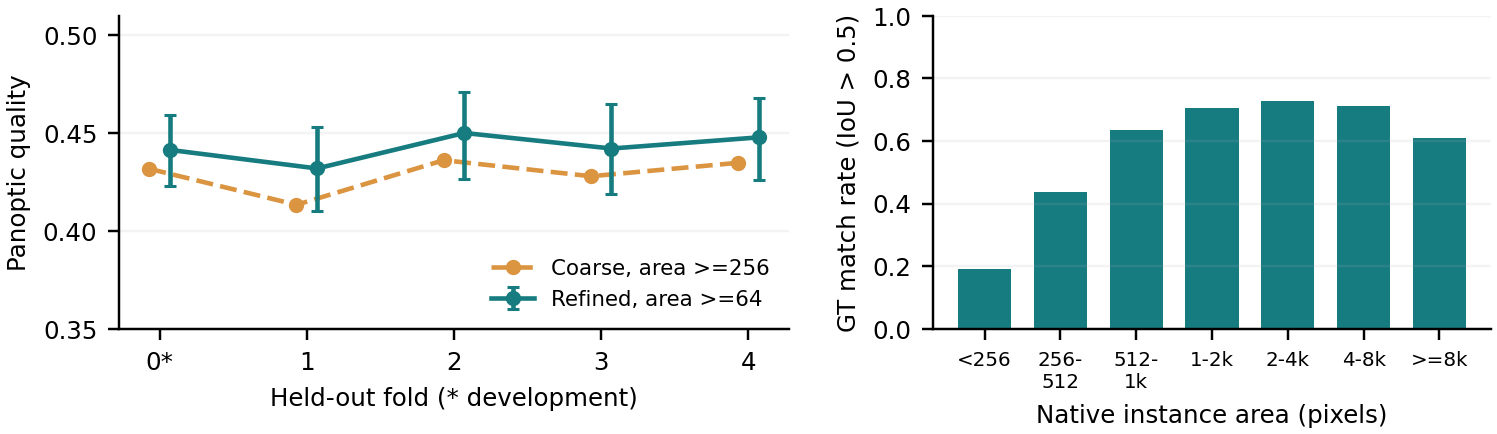

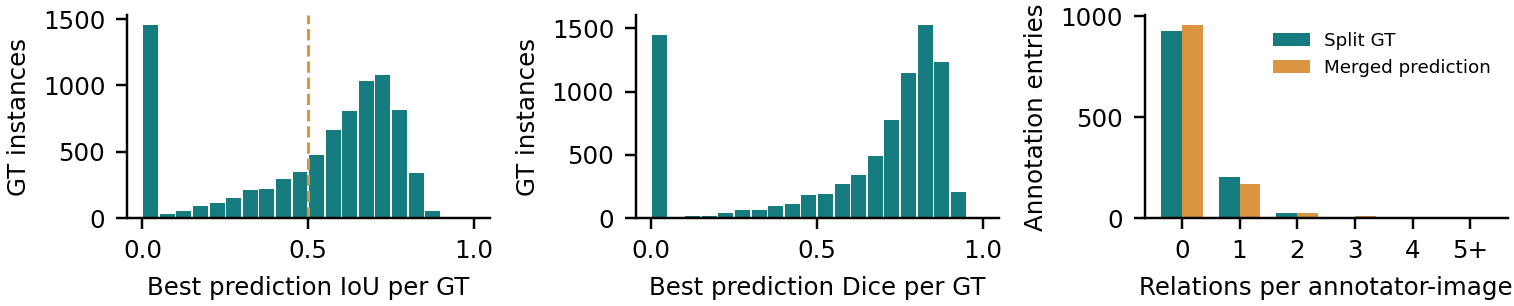

In [6]:
oof = json.loads((ROOT / "artifacts/oof_metrics.json").read_text())
summary = json.loads((ROOT / "report/report_summary.json").read_text())
display(pd.DataFrame([{"fold": x["fold"], "images": x["images"],
                       "coarse_PQ": x["coarse"]["official"]["pq"],
                       "refined_PQ": x["refined"]["official"]["pq"]} for x in oof["folds"]]))
print("All-fold paired bootstrap:", summary["all_folds"])
print("Confirmation folds:", summary["confirmation_folds"])
display(Image(filename=str(ROOT / "report/figures/validation.png")))
display(Image(filename=str(ROOT / "report/figures/distributions.png")))


## 5. Qualitative behavior and experiment decisions

The following examples include failures as well as successful matches. They are selected from OOF predictions by fixed target IoU levels, not presented as a random sample. Teal is the illustrated ground-truth instance and amber is prediction. The report and experiment ledger discuss resolution/TTA ablations, model diversity, negative results and system optimizations.

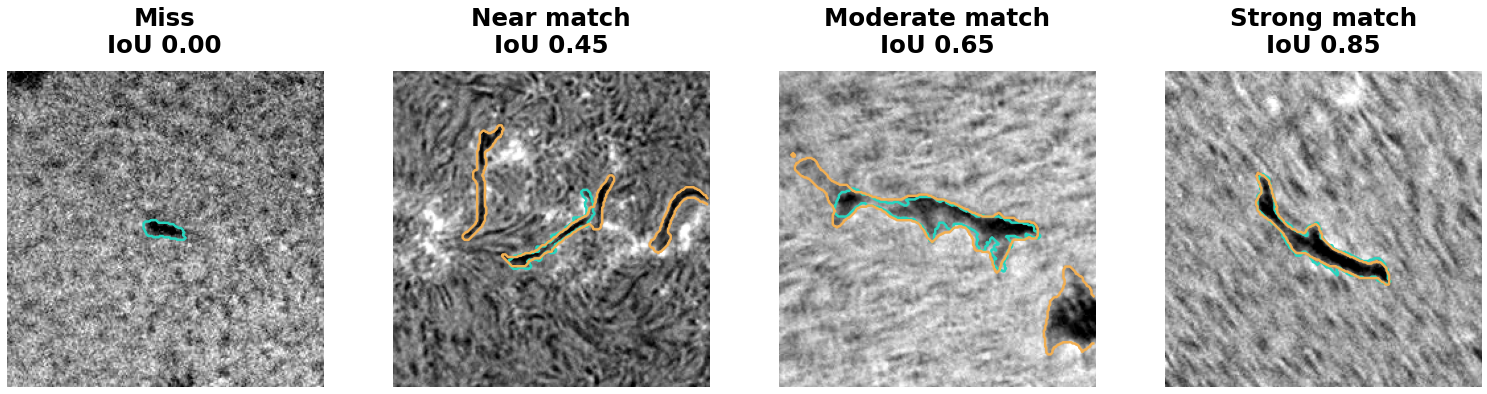

,name,kind,fold,size,completed_epoch,best_validation_pq
0,mask2former_swinb_f0_dense,instance,0,1024,12,0.275563
1,mask2former_swinb_f0_v1,instance,0,1024,8,0.000000
2,maskrcnn_r50v2_f0_1536,rcnn,0,1536,12,0.401478
3,maskrcnn_r50v2_f0_v1,rcnn,0,1024,40,0.379584
4,refiner_resnet18_f0_q05,refinement,0,384,12,NaN
5,refiner_resnet18_f0_v1,refinement,0,384,12,NaN
6,refiner_resnet18_f1_v1,refinement,1,384,12,NaN
7,refiner_resnet18_f2_v1,refinement,2,384,12,NaN
8,refiner_resnet18_f3_v1,refinement,3,384,12,NaN
9,refiner_resnet18_f4_v1,refinement,4,384,12,NaN


In [7]:
display(Image(filename=str(ROOT / "report/figures/qualitative.png")))
experiments = json.loads((ROOT / "artifacts/experiment_registry.json").read_text())
display(pd.DataFrame(experiments["runs"])[["name", "kind", "fold", "size", "completed_epoch", "best_validation_pq"]])


## 6. Reproduce the released test submission

Enable `RUN_INFERENCE` to download and checksum the published weights, prepare the official manifest if necessary, regenerate predictions from images, and independently decode/audit every submitted mask. All checkpoint paths and hashes are explicit. This route does not read the packaged CSV as an inference input.

On the reference GPU, allow several minutes for the ensemble plus data/weight downloads; the exact runtime depends on the selected final configuration. Output: `reproduced_submission/final/submission.csv`.

In [8]:
if RUN_INFERENCE:
    run("scripts.reproduce", "--data-dir", OFFICIAL_DATA,
        "--download-checkpoints", "--output", "reproduced_submission")
    display(pd.Series(json.loads((ROOT / "reproduced_submission/reproduction.json").read_text())))
else:
    print("Set RUN_INFERENCE=True after attaching official data to regenerate the submission.")
    print("Packaged reference SHA256:", release["csv_sha256"])


Set RUN_INFERENCE=True after attaching official data to regenerate the submission.
Packaged reference SHA256: 6071266cecbc1bce749f6fe0c2e2b0ca60e3aa5ab1f5f71a6e040ae8614ce23c


## 7. Verification and final artifacts

`python -m pytest tests -q` runs the numerical/provenance regression tests. The report PDF, release manifest, checkpoint manifest, submitted CSV and machine-readable metrics are linked from the README. Submission to the organizers also requires their Google registration form; a Kaggle CSV upload alone does not complete that registration.

In [9]:
for name in ["report/AnonTokyo_Report.pdf", "artifacts/release.json", "artifacts/checkpoints.json", "artifacts/submission.csv"]:
    path = ROOT / name
    print(name, "present" if path.is_file() else "missing")


report/AnonTokyo_Report.pdf present
artifacts/release.json present
artifacts/checkpoints.json present
artifacts/submission.csv present
